In [9]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [10]:
df = pd.read_csv('/content/house_prices_practice.csv')
df.head()

,Id,OverallQual,GrLivArea,GarageCars,TotalBsmtSF,YearBuilt,FullBath,BedroomAbvGr,LotArea,SalePrice
0,1,7,1560,0,1658,1969,2,1,8059,177106
1,2,4,2827,2,1319,2012,3,4,13530,301044
2,3,8,3920,0,841,2010,1,4,9010,360609
3,4,5,3044,0,1058,1998,0,4,13207,240556
4,5,7,801,1,2428,2020,0,1,9117,193656


In [11]:
df.shape

(300, 10)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   Id            300 non-null    int64
 1   OverallQual   300 non-null    int64
 2   GrLivArea     300 non-null    int64
 3   GarageCars    300 non-null    int64
 4   TotalBsmtSF   300 non-null    int64
 5   YearBuilt     300 non-null    int64
 6   FullBath      300 non-null    int64
 7   BedroomAbvGr  300 non-null    int64
 8   LotArea       300 non-null    int64
 9   SalePrice     300 non-null    int64
dtypes: int64(10)
memory usage: 23.6 KB


In [13]:
df.describe()

,Id,OverallQual,GrLivArea,GarageCars,TotalBsmtSF,YearBuilt,FullBath,BedroomAbvGr,LotArea,SalePrice
count,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000
mean,150.500000,5.326667,2307.386667,1.330000,1468.796667,1986.163333,1.523333,2.926667,8969.453333,252262.903333
std,86.746758,2.873001,1042.561303,1.109898,672.333705,21.377089,1.131543,1.456604,3753.531132,74998.055214
min,1.000000,1.000000,504.000000,0.000000,303.000000,1950.000000,0.000000,1.000000,2009.000000,82494.000000
25%,75.750000,3.000000,1392.250000,0.000000,903.000000,1967.000000,0.000000,2.000000,5996.250000,190355.250000
50%,150.500000,5.000000,2265.500000,1.000000,1502.000000,1986.000000,2.000000,3.000000,9031.000000,251292.500000
75%,225.250000,8.000000,3306.500000,2.000000,2129.500000,2004.250000,3.000000,4.000000,12316.000000,307105.000000
max,300.000000,10.000000,3998.000000,3.000000,2492.000000,2023.000000,3.000000,5.000000,14987.000000,435291.000000


In [14]:
df.isnull().sum()

,0
Id,0
OverallQual,0
GrLivArea,0
GarageCars,0
TotalBsmtSF,0
YearBuilt,0
FullBath,0
BedroomAbvGr,0
LotArea,0
SalePrice,0


In [15]:
df.duplicated().sum()

np.int64(0)

In [16]:
df.nunique()

,0
Id,300
OverallQual,10
GrLivArea,287
GarageCars,4
TotalBsmtSF,278
YearBuilt,73
FullBath,4
BedroomAbvGr,5
LotArea,296
SalePrice,300


REMOVE COLUMN

In [17]:
df = df.drop('Id', axis=1)


In [18]:
df.head()

,OverallQual,GrLivArea,GarageCars,TotalBsmtSF,YearBuilt,FullBath,BedroomAbvGr,LotArea,SalePrice
0,7,1560,0,1658,1969,2,1,8059,177106
1,4,2827,2,1319,2012,3,4,13530,301044
2,8,3920,0,841,2010,1,4,9010,360609
3,5,3044,0,1058,1998,0,4,13207,240556
4,7,801,1,2428,2020,0,1,9117,193656


DETECT OUTLIERS USING BOXPLOT

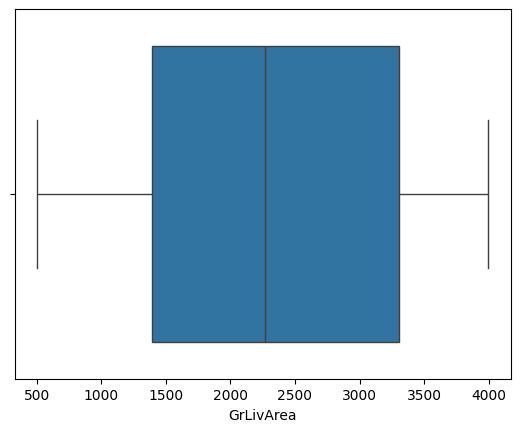

In [19]:
sns.boxplot(x=df['GrLivArea'])
plt.show()

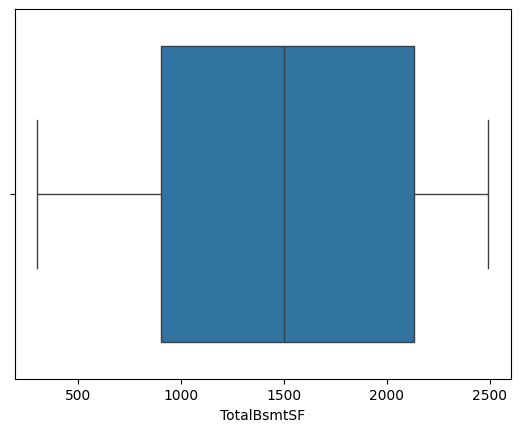

In [20]:
sns.boxplot(x=df['TotalBsmtSF'])
plt.show()

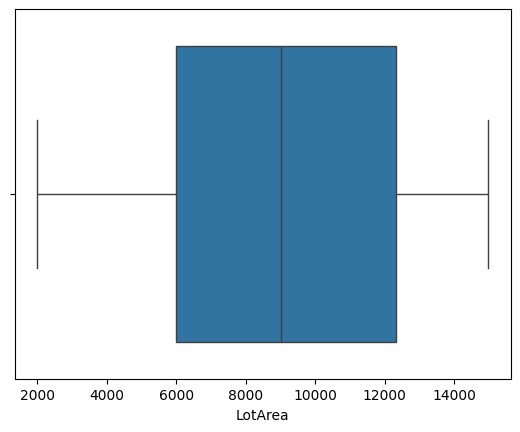

In [21]:
sns.boxplot(x=df['LotArea'])
plt.show()

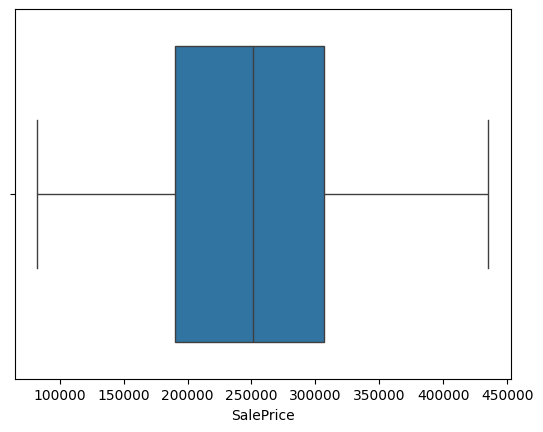

In [22]:
sns.boxplot(x=df['SalePrice'])
plt.show()

HISTOGRAM

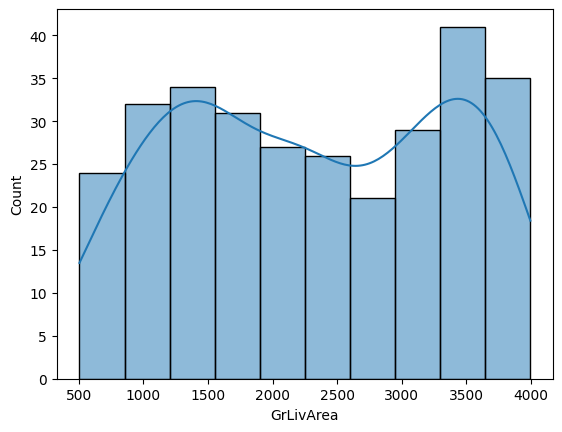

In [23]:
sns.histplot(df['GrLivArea'], kde=True)
plt.show()

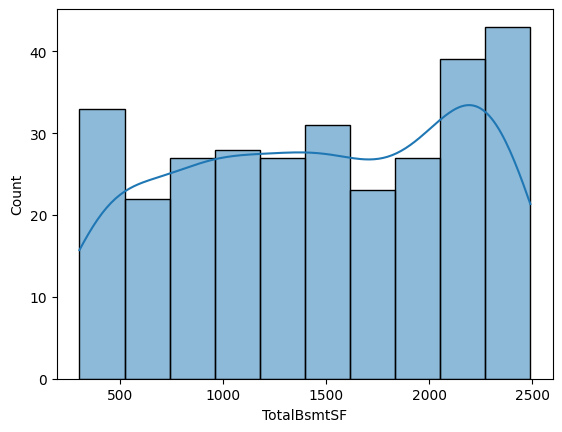

In [24]:
sns.histplot(df['TotalBsmtSF'], kde=True)
plt.show()

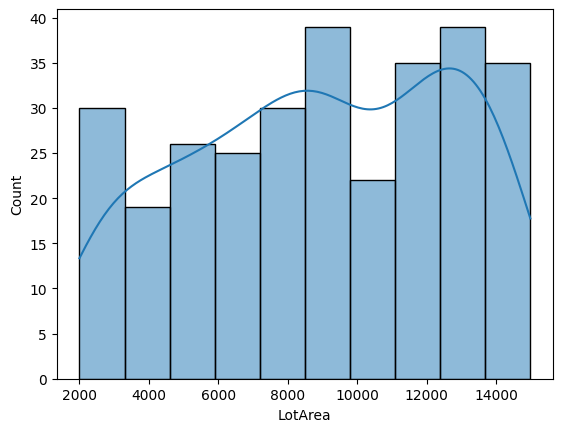

In [25]:
sns.histplot(df['LotArea'], kde=True)
plt.show()

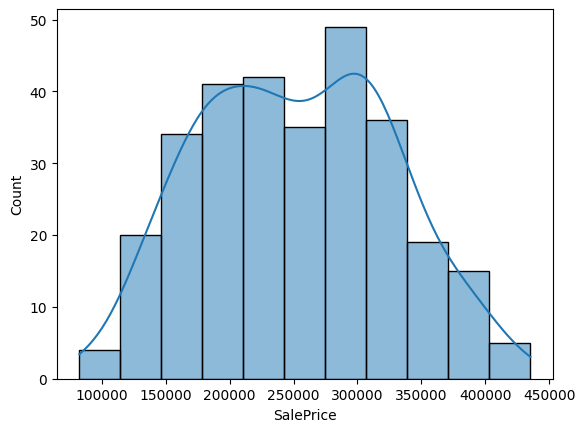

In [26]:
sns.histplot(df['SalePrice'], kde=True)
plt.show()

DETECT OUTLIERS USING ZSCORE METHOD

In [27]:
from scipy.stats import zscore

grliv_z = np.abs(zscore(df['GrLivArea']))

print("GrLivArea outliers:", (grliv_z > 3).sum())

GrLivArea outliers: 0


In [28]:
bsmt_z = np.abs(zscore(df['TotalBsmtSF']))

print("TotalBsmtSF outliers:", (bsmt_z > 3).sum())

TotalBsmtSF outliers: 0


In [29]:
lot_z = np.abs(zscore(df['LotArea']))

print("LotArea outliers:", (lot_z > 3).sum())

LotArea outliers: 0


In [30]:
price_z = np.abs(zscore(df['SalePrice']))

print("SalePrice outliers:", (price_z > 3).sum())

SalePrice outliers: 0


DEFINE TARGET Y AND FEATURE X

In [31]:
X = df.drop('SalePrice', axis=1)
y = df['SalePrice']

In [32]:
print(X.shape)
print(y.shape)

(300, 8)
(300,)


EDA ANALYSIS

In [33]:
print("Target:", "SalePrice")

Target: SalePrice


In [34]:
numeric_cols = df.select_dtypes(include="number").columns
print(numeric_cols)

Index(['OverallQual', 'GrLivArea', 'GarageCars', 'TotalBsmtSF', 'YearBuilt',
       'FullBath', 'BedroomAbvGr', 'LotArea', 'SalePrice'],
      dtype='object')


SALEPRICE DISTRIBUTION

In [35]:
import plotly.express as px

fig = px.histogram(
    df,
    x="SalePrice",
    nbins=30,
    title="Distribution of House Sale Prices"
)

fig.show()

SALEPRICE BOXPLOT

In [36]:
fig = px.box(
    df,
    y="SalePrice",
    title="Sale Price Boxplot"
)

fig.show()

GrLivArea vs SalePrice

In [37]:
fig = px.scatter(
    df,
    x="GrLivArea",
    y="SalePrice",
    title="Living Area vs Sale Price",
    trendline="ols"
)

fig.show()

OverallQual vs SalePrice

In [38]:
fig = px.box(
    df,
    x="OverallQual",
    y="SalePrice",
    title="Overall Quality vs Sale Price"
)

fig.show()

Average Price by Quality

In [39]:
avg_price = (
    df.groupby("OverallQual")["SalePrice"]
    .mean()
    .reset_index()
)

avg_price

,OverallQual,SalePrice
0,1,217836.342105
1,2,221203.125000
2,3,224128.444444
3,4,241780.806452
4,5,240817.653846
5,6,253421.230769
6,7,276980.878788
7,8,277104.636364
8,9,294908.580645
9,10,284144.863636


In [40]:
fig = px.bar(
    avg_price,
    x="OverallQual",
    y="SalePrice",
    title="Average Sale Price by Overall Quality"
)

fig.show()

GarageCars vs SalePrice

In [41]:
fig = px.box(
    df,
    x="GarageCars",
    y="SalePrice",
    title="Garage Capacity vs Sale Price"
)

fig.show()

BedroomAbvGr vs SalePrice

In [42]:
fig = px.box(
    df,
    x="BedroomAbvGr",
    y="SalePrice",
    title="Bedrooms vs Sale Price"
)

fig.show()

YearBuilt vs SalePrice

In [43]:
fig = px.scatter(
    df,
    x="YearBuilt",
    y="SalePrice",
    title="Year Built vs Sale Price"
)

fig.show()

Correlation Matrix

In [44]:
corr = df.corr(numeric_only=True)

corr

,OverallQual,GrLivArea,GarageCars,TotalBsmtSF,YearBuilt,FullBath,BedroomAbvGr,LotArea,SalePrice
OverallQual,1.000000,-0.116413,-0.017138,0.008098,0.005990,-0.047619,-0.056594,-0.030605,0.352899
GrLivArea,-0.116413,1.000000,0.056380,0.023471,0.032073,0.103215,-0.090480,-0.035433,0.745095
GarageCars,-0.017138,0.056380,1.000000,0.051605,-0.031599,0.125668,0.083287,-0.005316,0.351321
TotalBsmtSF,0.008098,0.023471,0.051605,1.000000,-0.050187,0.042792,-0.039197,-0.007753,0.250178
YearBuilt,0.005990,0.032073,-0.031599,-0.050187,1.000000,0.020098,-0.040859,0.091507,0.222142
FullBath,-0.047619,0.103215,0.125668,0.042792,0.020098,1.000000,0.037567,-0.061729,0.273731
BedroomAbvGr,-0.056594,-0.090480,0.083287,-0.039197,-0.040859,0.037567,1.000000,-0.000527,0.014113
LotArea,-0.030605,-0.035433,-0.005316,-0.007753,0.091507,-0.061729,-0.000527,1.000000,-0.038982
SalePrice,0.352899,0.745095,0.351321,0.250178,0.222142,0.273731,0.014113,-0.038982,1.000000


In [45]:
fig = px.imshow(
    corr,
    text_auto=True,
    aspect="auto",
    title="Correlation Heatmap"
)

fig.show()

sort SalePrice correlations

In [46]:
saleprice_corr = (
    corr["SalePrice"]
    .sort_values(ascending=False)
)

print(saleprice_corr)

SalePrice       1.000000
GrLivArea       0.745095
OverallQual     0.352899
GarageCars      0.351321
FullBath        0.273731
TotalBsmtSF     0.250178
YearBuilt       0.222142
BedroomAbvGr    0.014113
LotArea        -0.038982
Name: SalePrice, dtype: float64


TRAIN AND TEST SPLIT

In [47]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [48]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (240, 8)
X_test: (60, 8)
y_train: (240,)
y_test: (60,)


SCALING

In [49]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

LINEAR REGRESSION MODEL

In [50]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train_scaled, y_train)

LinearRegression()

In [51]:
y_pred = model.predict(X_test_scaled)

ACTUAL VS PREDICTED

In [52]:
comparison = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred
})

comparison.head(10)

,Actual,Predicted
0,224163,239161.363189
1,203881,190489.667985
2,380236,398000.957463
3,211664,223169.467552
4,122139,135188.395708
5,180067,180259.039807
6,275810,283708.271011
7,209025,204535.265477
8,213952,205837.941731
9,154885,171505.331960


CALCULATE ERROR

In [53]:
comparison['Error'] = (
    comparison['Actual'] - comparison['Predicted']
)

In [54]:
comparison.head(10)

,Actual,Predicted,Error
0,224163,239161.363189,-14998.363189
1,203881,190489.667985,13391.332015
2,380236,398000.957463,-17764.957463
3,211664,223169.467552,-11505.467552
4,122139,135188.395708,-13049.395708
5,180067,180259.039807,-192.039807
6,275810,283708.271011,-7898.271011
7,209025,204535.265477,4489.734523
8,213952,205837.941731,8114.058269
9,154885,171505.331960,-16620.331960


EVALUATION MATRICES
MEAN ABSOLUTE ERROR

In [55]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, y_pred)

print("MAE:", mae)

MAE: 10431.655979708512


MEAN SQUARED ERROR

In [56]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test, y_pred)

print("MSE:", mse)

MSE: 156386511.419044


RMSE

In [57]:
rmse = np.sqrt(mse)

print("RMSE:", rmse)

RMSE: 12505.459264618952


R2 SCORE

In [58]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)

print("R2 Score:", r2)

R2 Score: 0.9724369952260822


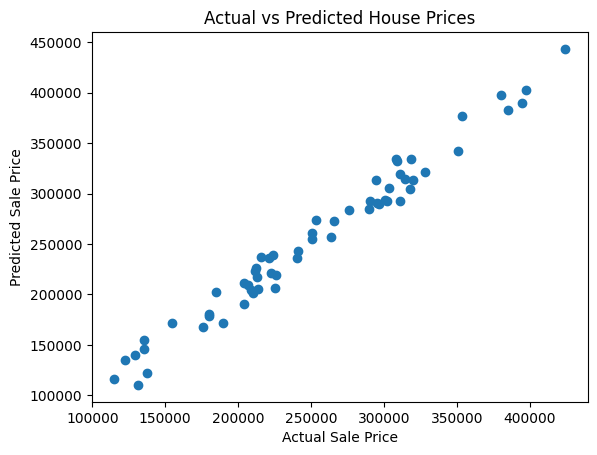

In [59]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Sale Price")
plt.ylabel("Predicted Sale Price")
plt.title("Actual vs Predicted House Prices")

plt.show()

In [60]:
new_house = pd.DataFrame({
    'OverallQual': [7],
    'GrLivArea': [2000],
    'GarageCars': [2],
    'TotalBsmtSF': [1500],
    'YearBuilt': [2010],
    'FullBath': [2],
    'BedroomAbvGr': [3],
    'LotArea': [9000]
})

new_house_scaled = scaler.transform(new_house)

predicted_price = model.predict(new_house_scaled)

print("Predicted House Price:", predicted_price[0])

Predicted House Price: 292707.4128166527


DecisionTree Classifier


In [61]:
from sklearn.tree import DecisionTreeRegressor

# Create model
dt_model = DecisionTreeRegressor(
    random_state=42
)

# Train model
dt_model.fit(X_train, y_train)

# Predictions
dt_pred = dt_model.predict(X_test)

print("Decision Tree Model Trained Successfully!")

Decision Tree Model Trained Successfully!


In [62]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

# Metrics
dt_mae = mean_absolute_error(y_test, dt_pred)
dt_mse = mean_squared_error(y_test, dt_pred)
dt_rmse = dt_mse ** 0.5
dt_r2 = r2_score(y_test, dt_pred)

print("MAE:", dt_mae)
print("MSE:", dt_mse)
print("RMSE:", dt_rmse)
print("R² Score:", dt_r2)

MAE: 35962.76666666667
MSE: 2219679456.3
RMSE: 47113.474254187626
R² Score: 0.6087831687310482


Linear Regression vs Decision Tree

In [63]:
import pandas as pd

results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree"
    ],

    "MAE": [
        10431.655979708512,
        dt_mae
    ],

    "MSE": [
        156386511.419044,
        dt_mse
    ],

    "RMSE": [
        12505.459264618952,
        dt_rmse
    ],

    "R2 Score": [
        0.9724369952260822,
        dt_r2
    ]
})

results

,Model,MAE,MSE,RMSE,R2 Score
0,Linear Regression,10431.655980,1.563865e+08,12505.459265,0.972437
1,Decision Tree,35962.766667,2.219679e+09,47113.474254,0.608783


In [64]:
print("Training R² Score:", dt_model.score(X_train, y_train))
print("Testing R² Score:", dt_model.score(X_test, y_test))

Training R² Score: 1.0
Testing R² Score: 0.6087831687310482


RandomForest Regressor

In [65]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

# Train the model
rf_model.fit(X_train, y_train)

# Predictions
rf_pred = rf_model.predict(X_test)

print("Random Forest Model Trained Successfully!")

Random Forest Model Trained Successfully!


In [66]:
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_mse = mean_squared_error(y_test, rf_pred)
rf_rmse = rf_mse ** 0.5
rf_r2 = r2_score(y_test, rf_pred)

print("MAE:", rf_mae)
print("MSE:", rf_mse)
print("RMSE:", rf_rmse)
print("R² Score:", rf_r2)

print("Training R² Score:", rf_model.score(X_train, y_train))
print("Testing R² Score:", rf_model.score(X_test, y_test))

MAE: 21414.515000000007
MSE: 751070707.1919668
RMSE: 27405.669252765325
R² Score: 0.8676243539162354
Training R² Score: 0.980227806688104
Testing R² Score: 0.8676243539162354


In [67]:
results.loc[len(results)] = [
    "Random Forest",
    rf_mae,
    rf_mse,
    rf_rmse,
    rf_r2
]

results

,Model,MAE,MSE,RMSE,R2 Score
0,Linear Regression,10431.655980,1.563865e+08,12505.459265,0.972437
1,Decision Tree,35962.766667,2.219679e+09,47113.474254,0.608783
2,Random Forest,21414.515000,7.510707e+08,27405.669253,0.867624


Gradient Boosting Regressor

In [68]:
from sklearn.ensemble import GradientBoostingRegressor

# Create model
gb_model = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

# Train
gb_model.fit(X_train, y_train)

# Predict
gb_pred = gb_model.predict(X_test)

print("Gradient Boosting Model Trained Successfully!")

Gradient Boosting Model Trained Successfully!


In [69]:
gb_mae = mean_absolute_error(y_test, gb_pred)
gb_mse = mean_squared_error(y_test, gb_pred)
gb_rmse = gb_mse ** 0.5
gb_r2 = r2_score(y_test, gb_pred)

print("MAE:", gb_mae)
print("MSE:", gb_mse)
print("RMSE:", gb_rmse)
print("R² Score:", gb_r2)

print("\nTraining R² Score:", gb_model.score(X_train, y_train))
print("Testing R² Score:", gb_model.score(X_test, y_test))

MAE: 18975.75111869006
MSE: 565926105.041985
RMSE: 23789.201437668835
R² Score: 0.9002559505073952

Training R² Score: 0.9799988980987298
Testing R² Score: 0.9002559505073952


In [70]:
results.loc[len(results)] = [
    "Gradient Boosting",
    gb_mae,
    gb_mse,
    gb_rmse,
    gb_r2
]

results

,Model,MAE,MSE,RMSE,R2 Score
0,Linear Regression,10431.655980,1.563865e+08,12505.459265,0.972437
1,Decision Tree,35962.766667,2.219679e+09,47113.474254,0.608783
2,Random Forest,21414.515000,7.510707e+08,27405.669253,0.867624
3,Gradient Boosting,18975.751119,5.659261e+08,23789.201438,0.900256


In [71]:
results = results.sort_values(
    by="R2 Score",
    ascending=False
).reset_index(drop=True)

results

,Model,MAE,MSE,RMSE,R2 Score
0,Linear Regression,10431.655980,1.563865e+08,12505.459265,0.972437
1,Gradient Boosting,18975.751119,5.659261e+08,23789.201438,0.900256
2,Random Forest,21414.515000,7.510707e+08,27405.669253,0.867624
3,Decision Tree,35962.766667,2.219679e+09,47113.474254,0.608783


Cross Validation             DEfine Model


In [72]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# 5-fold cross validation
cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

models = {
    "Linear Regression": LinearRegression(),

    "Decision Tree": DecisionTreeRegressor(
        random_state=42
    ),

    "Random Forest": RandomForestRegressor(
        n_estimators=100,
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=100,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )
}

In [73]:
cv_results_list = []

for name, model in models.items():

    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring="r2"
    )

    cv_results_list.append({
        "Model": name,
        "Mean CV R²": scores.mean(),
        "Standard Deviation": scores.std()
    })

cv_results = pd.DataFrame(cv_results_list)

cv_results = cv_results.sort_values(
    by="Mean CV R²",
    ascending=False
).reset_index(drop=True)

cv_results

,Model,Mean CV R²,Standard Deviation
0,Linear Regression,0.976723,0.001830
1,Gradient Boosting,0.878208,0.009539
2,Random Forest,0.844800,0.013192
3,Decision Tree,0.601501,0.051703


 Hyperparameter tuning



In [74]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# ==================================================
# 1. DECISION TREE HYPERPARAMETER TUNING
# ==================================================

dt_params = {
    "max_depth": [3, 5, 7, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

dt_grid = GridSearchCV(
    estimator=DecisionTreeRegressor(random_state=42),
    param_grid=dt_params,
    cv=cv,
    scoring="r2",
    n_jobs=-1
)

dt_grid.fit(X_train, y_train)

best_dt = dt_grid.best_estimator_

print("=" * 60)
print("DECISION TREE")
print("=" * 60)
print("Best Parameters:", dt_grid.best_params_)
print("Best CV R² Score:", dt_grid.best_score_)


# ==================================================
# 2. RANDOM FOREST HYPERPARAMETER TUNING
# ==================================================

rf_params = {
    "n_estimators": [100, 200],
    "max_depth": [5, 10, 20, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

rf_grid = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=rf_params,
    cv=cv,
    scoring="r2",
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

best_rf = rf_grid.best_estimator_

print("\n" + "=" * 60)
print("RANDOM FOREST")
print("=" * 60)
print("Best Parameters:", rf_grid.best_params_)
print("Best CV R² Score:", rf_grid.best_score_)


# ==================================================
# 3. GRADIENT BOOSTING HYPERPARAMETER TUNING
# ==================================================

gb_params = {
    "n_estimators": [50, 100, 200],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [2, 3, 4],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

gb_grid = GridSearchCV(
    estimator=GradientBoostingRegressor(random_state=42),
    param_grid=gb_params,
    cv=cv,
    scoring="r2",
    n_jobs=-1
)

gb_grid.fit(X_train, y_train)

best_gb = gb_grid.best_estimator_

print("\n" + "=" * 60)
print("GRADIENT BOOSTING")
print("=" * 60)
print("Best Parameters:", gb_grid.best_params_)
print("Best CV R² Score:", gb_grid.best_score_)


# ==================================================
# FINAL TUNING SUMMARY
# ==================================================

print("\n" + "=" * 60)
print("FINAL TUNING SUMMARY")
print("=" * 60)

print("\nDecision Tree:")
print("Best Parameters:", dt_grid.best_params_)
print("Best CV R²:", dt_grid.best_score_)

print("\nRandom Forest:")
print("Best Parameters:", rf_grid.best_params_)
print("Best CV R²:", rf_grid.best_score_)

print("\nGradient Boosting:")
print("Best Parameters:", gb_grid.best_params_)
print("Best CV R²:", gb_grid.best_score_)

DECISION TREE
Best Parameters: {'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 5}
Best CV R² Score: 0.6752165103770679

RANDOM FOREST
Best Parameters: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best CV R² Score: 0.844800080372145

GRADIENT BOOSTING
Best Parameters: {'learning_rate': 0.1, 'max_depth': 2, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}
Best CV R² Score: 0.9270976702007628

FINAL TUNING SUMMARY

Decision Tree:
Best Parameters: {'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 5}
Best CV R²: 0.6752165103770679

Random Forest:
Best Parameters: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best CV R²: 0.844800080372145

Gradient Boosting:
Best Parameters: {'learning_rate': 0.1, 'max_depth': 2, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}
Best CV R²: 0.9270976702007628


In [75]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pandas as pd
import numpy as np

# ==========================================================
# Linear Regression ko dubara train kar rahe hain
# ==========================================================

final_lr = LinearRegression()
final_lr.fit(X_train, y_train)

# Models for final comparison
final_models = {
    "Linear Regression": final_lr,
    "Tuned Decision Tree": best_dt,
    "Tuned Random Forest": best_rf,
    "Tuned Gradient Boosting": best_gb
}

final_results_list = []

for name, model in final_models.items():

    # Prediction on untouched test data
    predictions = model.predict(X_test)

    # Metrics
    mae = mean_absolute_error(y_test, predictions)
    mse = mean_squared_error(y_test, predictions)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, predictions)

    # Train score
    train_r2 = model.score(X_train, y_train)

    # Test score
    test_r2 = model.score(X_test, y_test)

    final_results_list.append({
        "Model": name,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "Training R²": train_r2,
        "Testing R²": test_r2
    })

# Create final table
final_results = pd.DataFrame(final_results_list)

# Sort by Testing R²
final_results = final_results.sort_values(
    by="Testing R²",
    ascending=False
).reset_index(drop=True)

final_results

,Model,MAE,MSE,RMSE,Training R²,Testing R²
0,Linear Regression,10431.655980,1.563865e+08,12505.459265,0.979036,0.972437
1,Tuned Gradient Boosting,13084.376692,2.679434e+08,16368.977357,0.989809,0.952775
2,Tuned Random Forest,21414.515000,7.510707e+08,27405.669253,0.980228,0.867624
3,Tuned Decision Tree,33382.120920,1.668534e+09,40847.690417,0.900940,0.705922


In [76]:
best_model_name = final_results.iloc[0]["Model"]

final_model = final_models[best_model_name]

print("🏆 FINAL BEST MODEL:", best_model_name)
print("\nFinal Results:")
print(final_results)

🏆 FINAL BEST MODEL: Linear Regression

Final Results:
                     Model           MAE           MSE          RMSE  \
0        Linear Regression  10431.655980  1.563865e+08  12505.459265   
1  Tuned Gradient Boosting  13084.376692  2.679434e+08  16368.977357   
2      Tuned Random Forest  21414.515000  7.510707e+08  27405.669253   
3      Tuned Decision Tree  33382.120920  1.668534e+09  40847.690417   

   Training R²  Testing R²  
0     0.979036    0.972437  
1     0.989809    0.952775  
2     0.980228    0.867624  
3     0.900940    0.705922  


In [77]:
import os

PROJECT_FOLDER = "/content/drive/MyDrive/House_Price_Prediction"

os.makedirs(PROJECT_FOLDER, exist_ok=True)

print("Project folder ready!")
print(PROJECT_FOLDER)

Project folder ready!
/content/drive/MyDrive/House_Price_Prediction


In [78]:
from sklearn.linear_model import LinearRegression

final_model = LinearRegression()
final_model.fit(X_train, y_train)

print("Final model trained successfully!")

Final model trained successfully!


In [79]:
import os
import joblib

PROJECT_FOLDER = "/content/drive/MyDrive/House_Price_Prediction"

os.makedirs(PROJECT_FOLDER, exist_ok=True)

MODEL_PATH = os.path.join(
    PROJECT_FOLDER,
    "house_price_model.pkl"
)

joblib.dump(final_model, MODEL_PATH)

print("Model saved successfully!")
print(MODEL_PATH)

Model saved successfully!
/content/drive/MyDrive/House_Price_Prediction/house_price_model.pkl


In [80]:
import os

PROJECT_FOLDER = "/content/drive/MyDrive/House_Price_Prediction"

os.makedirs(PROJECT_FOLDER, exist_ok=True)

print("Folder ready:", PROJECT_FOLDER)
print(os.listdir(PROJECT_FOLDER))

Folder ready: /content/drive/MyDrive/House_Price_Prediction
['house_price_model.pkl']


In [81]:
import os
import joblib
final_model = joblib.load(MODEL_PATH)

print("House Price Prediction Model Loaded Successfully!")

House Price Prediction Model Loaded Successfully!


app.py

In [120]:
%%writefile /content/drive/MyDrive/House_Price_Prediction/app.py
import streamlit as st
import pandas as pd
import numpy as np
import joblib
import os
import textwrap

# ============================================================
# PAGE CONFIGURATION
# ============================================================

st.set_page_config(
    page_title="HOMNIQ AI | House Price Prediction",
    page_icon="🏡",
    layout="wide",
    initial_sidebar_state="collapsed"
)
# =========================
# MODEL PATH
# =========================

BASE_DIR = os.path.dirname(os.path.abspath(__file__))

MODEL_PATH = os.path.join(
    BASE_DIR,
    "house_price_model.pkl"
)

# ============================================================
# LOAD MODEL
# ============================================================

@st.cache_resource
def load_model():
    if not os.path.exists(MODEL_PATH):
        st.error("⚠️ Model file not found.")
        st.write("Expected path:", MODEL_PATH)
        return None

    try:
        model = joblib.load(MODEL_PATH)
        return model

    except Exception as e:
        st.error("⚠️ Model file could not be loaded.")
        st.error(f"Error: {e}")
        return None


model = load_model()


# ============================================================
# IMPORTANT HTML RENDER FUNCTION
# THIS PREVENTS <div> CODE FROM SHOWING ON SCREEN
# ============================================================

def render_html(content):
    st.html(
        textwrap.dedent(content).strip()
    )


# ============================================================
# CSS
# ============================================================

render_html("""
<style>

/* =========================
   GLOBAL
========================= */

.stApp {
    background:
        radial-gradient(circle at 90% 5%, #e8f1ee 0%, transparent 25%),
        linear-gradient(135deg, #f7f8f6 0%, #eef3f0 100%);
}

.block-container {
    padding-top: 1.5rem;
    padding-bottom: 2rem;
    max-width: 1500px;
}

/* Remove unnecessary Streamlit spaces */
[data-testid="stHeader"] {
    background: transparent;
}

/* =========================
   ANIMATIONS
========================= */

@keyframes fadeUp {
    0% {
        opacity: 0;
        transform: translateY(25px);
    }

    100% {
        opacity: 1;
        transform: translateY(0);
    }
}

@keyframes floating {
    0%, 100% {
        transform: translateY(0px);
    }

    50% {
        transform: translateY(-8px);
    }
}

@keyframes glow {
    0%, 100% {
        box-shadow: 0 0 0 rgba(46, 125, 91, 0);
    }

    50% {
        box-shadow: 0 0 30px rgba(46, 125, 91, 0.18);
    }
}


/* =========================
   SIDEBAR
========================= */

[data-testid="stSidebar"] {
    background: #ffffff;
    border-right: 1px solid #dfe7e2;
}

[data-testid="stSidebar"] * {
    color: #24342b;
}


/* =========================
   HERO
========================= */

.hero-card {
    position: relative;
    overflow: hidden;
    min-height: 300px;
    padding: 55px;
    border-radius: 28px;
    background:
        linear-gradient(
            90deg,
            rgba(20, 40, 31, 0.96) 0%,
            rgba(20, 40, 31, 0.82) 45%,
            rgba(20, 40, 31, 0.15) 100%
        ),
        url("https://images.unsplash.com/photo-1600585154340-be6161a56a0c?auto=format&fit=crop&w=1800&q=85");

    background-size: cover;
    background-position: center;

    animation: fadeUp 0.8s ease;
    box-shadow: 0 18px 45px rgba(25, 45, 34, 0.12);
}

.hero-tag {
    display: inline-block;
    background: rgba(255,255,255,0.16);
    color: #d9f2df;
    padding: 8px 18px;
    border-radius: 30px;
    font-size: 13px;
    letter-spacing: 1px;
    margin-bottom: 18px;
}

.hero-title {
    font-size: 52px;
    font-weight: 800;
    line-height: 1.08;
    color: white;
    max-width: 650px;
}

.hero-title span {
    color: #8ee0a8;
}

.hero-description {
    margin-top: 20px;
    color: #e5eee8;
    font-size: 18px;
    line-height: 1.7;
    max-width: 580px;
}

.hero-mini-stats {
    display: flex;
    gap: 28px;
    margin-top: 28px;
}

.hero-stat {
    color: white;
}

.hero-stat-number {
    font-size: 22px;
    font-weight: 800;
}

.hero-stat-label {
    font-size: 12px;
    opacity: 0.75;
}


/* =========================
   SECTION
========================= */

.section-title {
    margin-top: 35px;
    margin-bottom: 6px;
    font-size: 28px;
    font-weight: 750;
    color: #1d3127;
}

.section-subtitle {
    color: #718077;
    margin-bottom: 20px;
}


/* =========================
   CARDS
========================= */

.custom-card {
    background: rgba(255,255,255,0.96);
    border: 1px solid #e0e8e2;
    padding: 28px;
    border-radius: 22px;
    box-shadow: 0 10px 30px rgba(38, 57, 45, 0.06);
    animation: fadeUp 0.7s ease;
}

.custom-card:hover {
    transform: translateY(-3px);
    transition: 0.3s;
    box-shadow: 0 18px 40px rgba(38, 57, 45, 0.10);
}


/* =========================
   RESULT CARD
========================= */

.result-card {
    background:
        linear-gradient(145deg, #16382a, #24513e);

    color: white;
    padding: 38px;
    border-radius: 25px;
    text-align: center;
    min-height: 350px;

    animation:
        fadeUp 0.8s ease,
        glow 3s infinite;
}

.result-label {
    font-size: 13px;
    letter-spacing: 1.5px;
    color: #b8dbc3;
}

.result-title {
    margin-top: 20px;
    font-size: 22px;
}

.price-value {
    font-size: 48px;
    font-weight: 800;
    margin: 15px 0;
    color: #91e7ad;
}

.result-description {
    color: #d8e8dc;
    line-height: 1.6;
}


/* =========================
   FEATURE CARDS
========================= */

.feature-card {
    background: white;
    border: 1px solid #e3ebe5;
    padding: 20px;
    border-radius: 18px;
    min-height: 130px;
}

.feature-icon {
    font-size: 28px;
}

.feature-title {
    font-size: 17px;
    font-weight: 700;
    color: #20352a;
    margin-top: 10px;
}

.feature-text {
    font-size: 13px;
    color: #748078;
    margin-top: 7px;
}


/* =========================
   FOOTER
========================= */

.footer {
    margin-top: 50px;
    padding: 25px;
    text-align: center;
    color: #66746b;
    border-top: 1px solid #dfe7e2;
}

.footer-name {
    color: #2f8256;
    font-weight: 800;
}


/* =========================
   BUTTON
========================= */

.stButton > button {
    width: 100%;
    height: 55px;

    border: none;
    border-radius: 14px;

    background:
        linear-gradient(
            135deg,
            #2f7f58,
            #5bb77a
        );

    color: white;

    font-size: 17px;
    font-weight: 700;

    transition: all 0.3s ease;

    box-shadow:
        0 10px 20px
        rgba(47, 127, 88, 0.18);
}

.stButton > button:hover {
    transform: translateY(-2px);
    box-shadow:
        0 15px 28px
        rgba(47, 127, 88, 0.28);
}


/* =========================
   INPUTS
========================= */

.stNumberInput input {
    border-radius: 10px !important;
}

.stNumberInput label {
    font-weight: 600 !important;
    color: #324239 !important;
}


/* ============================================================
   RESPONSIVE DESIGN — keeps desktop design unchanged
   ============================================================ */

@media (max-width: 1100px) {
    .block-container {
        padding-left: 1.25rem;
        padding-right: 1.25rem;
    }
    .hero-card {
        padding: 42px;
    }
    .hero-title {
        font-size: 44px;
    }
}

@media (max-width: 768px) {
    .block-container {
        padding: 0.8rem 0.75rem 1.5rem 0.75rem;
        max-width: 100%;
    }

    .hero-card {
        min-height: 280px;
        padding: 30px 24px;
        border-radius: 22px;
        background-position: center;
    }

    .hero-title {
        font-size: 34px;
        line-height: 1.12;
        max-width: 100%;
    }

    .hero-description {
        font-size: 15px;
        line-height: 1.55;
        max-width: 100%;
        margin-top: 14px;
    }

    .hero-tag {
        font-size: 10px;
        padding: 7px 12px;
        margin-bottom: 12px;
    }

    .hero-mini-stats {
        flex-wrap: wrap;
        gap: 14px 22px;
        margin-top: 20px;
    }

    .hero-stat-number {
        font-size: 18px;
    }

    .hero-stat-label {
        font-size: 9px;
    }

    .section-title {
        font-size: 24px;
        margin-top: 25px;
    }

    .section-subtitle {
        font-size: 14px;
        line-height: 1.5;
    }

    .custom-card {
        padding: 18px;
        border-radius: 18px;
    }

    .result-card {
        min-height: 300px;
        padding: 28px 18px;
        border-radius: 20px;
    }

    .price-value {
        font-size: 38px;
    }

    .result-title {
        font-size: 19px;
    }

    .feature-card {
        min-height: auto;
        padding: 18px;
        margin-bottom: 12px;
    }

    .footer {
        margin-top: 30px;
        padding: 20px 10px;
        font-size: 13px;
    }

    /* Streamlit's native columns stack cleanly on small screens */
    [data-testid="stHorizontalBlock"] {
        flex-wrap: wrap;
    }

    /* Prevent tables/charts from breaking the viewport */
    [data-testid="stDataFrame"],
    [data-testid="stArrowVegaLiteChart"],
    [data-testid="stVegaLiteChart"] {
        max-width: 100%;
        overflow-x: auto;
    }

    .stButton > button {
        height: 52px;
        font-size: 15px;
    }

    .stNumberInput input {
        font-size: 16px !important;
    }
}

@media (max-width: 480px) {
    .block-container {
        padding-left: 0.55rem;
        padding-right: 0.55rem;
    }

    .hero-card {
        padding: 24px 18px;
        min-height: 300px;
        border-radius: 18px;
    }

    .hero-title {
        font-size: 29px;
    }

    .hero-description {
        font-size: 14px;
    }

    .hero-mini-stats {
        display: grid;
        grid-template-columns: repeat(3, 1fr);
        gap: 8px;
    }

    .hero-stat-number {
        font-size: 16px;
    }

    .hero-stat-label {
        font-size: 8px;
        line-height: 1.25;
    }

    .section-title {
        font-size: 21px;
    }

    .price-value {
        font-size: 32px;
    }

    .feature-title {
        font-size: 16px;
    }

    .feature-text {
        font-size: 12px;
    }
}

/* Slightly reduce sidebar width on medium screens */
@media (min-width: 769px) and (max-width: 1200px) {
    [data-testid="stSidebar"] {
        min-width: 240px;
        max-width: 260px;
    }
}

</style>
""")


# ============================================================
# SIDEBAR
# ============================================================

with st.sidebar:

    render_html("""
    <div style="
        padding: 20px 5px 25px 5px;
        border-bottom: 1px solid #e2e9e4;
        margin-bottom: 20px;
    ">
        <div style="
            font-size: 26px;
            font-weight: 800;
            color: #204431;
        ">
            🏡 HOMNIQ
        </div>

        <div style="
            color: #6f7f75;
            font-size: 13px;
            margin-top: 5px;
        ">
            AI Real Estate Intelligence
        </div>
    </div>
    """)

    page = st.radio(
        "Navigation",
        [
            "🏠 Prediction",
            "📊 Model Insights",
            "ℹ️ About Project"
        ],
        label_visibility="collapsed"
    )

    st.markdown("---")

    render_html("""
    <div style="
        background: #eef6f0;
        border: 1px solid #d9eadc;
        padding: 18px;
        border-radius: 15px;
        margin-top: 20px;
    ">
        <div style="
            font-weight: 700;
            color: #286040;
            margin-bottom: 7px;
        ">
            🤖 AI Powered
        </div>

        <div style="
            font-size: 13px;
            color: #637368;
            line-height: 1.5;
        ">
            Intelligent property value estimation using Machine Learning.
        </div>
    </div>
    """)


# ============================================================
# PREDICTION PAGE
# ============================================================

if page == "🏠 Prediction":

    # HERO
    render_html("""
    <div class="hero-card">

        <div class="hero-tag">
            ✦ MACHINE LEARNING • REAL ESTATE
        </div>

        <div class="hero-title">
            Predict Your <br>
            <span>House Price</span> with AI
        </div>

        <div class="hero-description">
            Get an intelligent property value estimate using a
            trained Machine Learning regression model.
        </div>

        <div class="hero-mini-stats">

            <div class="hero-stat">
                <div class="hero-stat-number">97.24%</div>
                <div class="hero-stat-label">BEST R² SCORE</div>
            </div>

            <div class="hero-stat">
                <div class="hero-stat-number">4</div>
                <div class="hero-stat-label">MODELS TESTED</div>
            </div>

            <div class="hero-stat">
                <div class="hero-stat-number">8</div>
                <div class="hero-stat-label">FEATURES USED</div>
            </div>

        </div>

    </div>
    """)

    render_html("""
    <div class="section-title">
        Property Information
    </div>

    <div class="section-subtitle">
        Enter the property details below to generate an estimated market price.
    </div>
    """)

    # MAIN LAYOUT
    col1, col2 = st.columns([1.25, 0.75], gap="large")

    # ========================================================
    # INPUT FORM
    # ========================================================

    with col1:

        render_html("""
        <div class="custom-card">
        """)

        c1, c2 = st.columns(2)

        with c1:
            overall_qual = st.number_input(
                "Overall Quality",
                min_value=1,
                max_value=10,
                value=6,
                step=1
            )

            gr_liv_area = st.number_input(
                "Living Area (sq ft)",
                min_value=300,
                value=1500,
                step=50
            )

            garage_cars = st.number_input(
                "Garage Capacity",
                min_value=0,
                max_value=5,
                value=2,
                step=1
            )

            total_bsmt_sf = st.number_input(
                "Basement Area (sq ft)",
                min_value=0,
                value=900,
                step=50
            )

        with c2:

            year_built = st.number_input(
                "Year Built",
                min_value=1800,
                max_value=2026,
                value=2005,
                step=1
            )

            full_bath = st.number_input(
                "Full Bathrooms",
                min_value=0,
                max_value=10,
                value=2,
                step=1
            )

            bedrooms = st.number_input(
                "Bedrooms",
                min_value=0,
                max_value=10,
                value=3,
                step=1
            )

            lot_area = st.number_input(
                "Lot Area (sq ft)",
                min_value=1000,
                value=8500,
                step=100
            )

        predict_button = st.button(
            "✨ Generate AI Price Estimate"
        )

        render_html("""
        </div>
        """)


    # ========================================================
    # RESULT SECTION
    # ========================================================

    with col2:

        if predict_button:

            input_data = pd.DataFrame({
                "OverallQual": [overall_qual],
                "GrLivArea": [gr_liv_area],
                "GarageCars": [garage_cars],
                "TotalBsmtSF": [total_bsmt_sf],
                "YearBuilt": [year_built],
                "FullBath": [full_bath],
                "BedroomAbvGr": [bedrooms],
                "LotArea": [lot_area]
            })

            prediction = model.predict(input_data)[0]

            render_html(f"""
            <div class="result-card">

                <div style="font-size:55px;">
                    🏠
                </div>

                <div class="result-label">
                    AI ESTIMATED PROPERTY VALUE
                </div>

                <div class="result-title">
                    Predicted House Price
                </div>

                <div class="price-value">
                    ${prediction:,.0f}
                </div>

                <div class="result-description">
                    Based on the entered property characteristics
                    and the trained Linear Regression model.
                </div>

                <div style="
                    margin-top: 25px;
                    padding-top: 20px;
                    border-top: 1px solid rgba(255,255,255,0.15);
                    font-size: 13px;
                    color: #c8dbce;
                ">
                    ✓ Model R² Score: 97.24%<br>
                    ✓ Prediction Status: Completed
                </div>

            </div>
            """)

        else:

            render_html("""
            <div class="result-card">

                <div style="
                    font-size: 70px;
                    animation: floating 3s ease-in-out infinite;
                ">
                    🏡
                </div>

                <div class="result-label">
                    AI PREDICTION DASHBOARD
                </div>

                <div class="result-title">
                    Your Property Estimate
                </div>

                <div style="
                    margin-top: 25px;
                    color: #d8e8dc;
                    line-height: 1.7;
                ">
                    Enter the property information and click
                    <b>Generate AI Price Estimate</b>
                    to receive a predicted house value.
                </div>

            </div>
            """)


    # ========================================================
    # FEATURES
    # ========================================================

    render_html("""
    <div class="section-title">
        Intelligent Property Analysis
    </div>

    <div class="section-subtitle">
        Combining real estate data with Machine Learning for smarter predictions.
    </div>
    """)

    f1, f2, f3 = st.columns(3)

    with f1:
        render_html("""
        <div class="feature-card">
            <div class="feature-icon">📐</div>
            <div class="feature-title">Property Features</div>
            <div class="feature-text">
                Analyzes living area, lot size, basement and room details.
            </div>
        </div>
        """)

    with f2:
        render_html("""
        <div class="feature-card">
            <div class="feature-icon">🧠</div>
            <div class="feature-title">Machine Learning</div>
            <div class="feature-text">
                Uses a trained regression model for intelligent price estimation.
            </div>
        </div>
        """)

    with f3:
        render_html("""
        <div class="feature-card">
            <div class="feature-icon">📈</div>
            <div class="feature-title">High Performance</div>
            <div class="feature-text">
                Final Linear Regression model achieved a 97.24% testing R² score.
            </div>
        </div>
        """)


# ============================================================
# MODEL INSIGHTS PAGE
# ============================================================

elif page == "📊 Model Insights":

    render_html("""
    <div class="section-title">
        Model Performance
    </div>

    <div class="section-subtitle">
        Comparison of Machine Learning models tested for house price prediction.
    </div>
    """)

    model_data = pd.DataFrame({
        "Model": [
            "Linear Regression",
            "Gradient Boosting",
            "Random Forest",
            "Decision Tree"
        ],

        "Testing R²": [
            0.972437,
            0.952775,
            0.867624,
            0.705922
        ],

        "RMSE": [
            12505.46,
            16368.98,
            27405.67,
            40847.69
        ]
    })

    st.dataframe(
        model_data,
        use_container_width=True,
        hide_index=True
    )

    st.bar_chart(
        model_data.set_index("Model")["Testing R²"]
    )

    render_html("""
    <div class="custom-card" style="margin-top:25px;">

        <div style="
            font-size:22px;
            font-weight:800;
            color:#20352a;
        ">
            🏆 Final Model Selection
        </div>

        <div style="
            margin-top:15px;
            color:#68766d;
            line-height:1.8;
        ">
            Linear Regression was selected as the final model because
            it achieved the highest Testing R² score of <b>97.24%</b>
            and the lowest prediction error among the tested models.
        </div>

    </div>
    """)


# ============================================================
# ABOUT PAGE
# ============================================================

elif page == "ℹ️ About Project":

    render_html("""
    <div class="section-title">
        About HOMNIQ AI
    </div>

    <div class="section-subtitle">
        An end-to-end Machine Learning project for intelligent real estate price estimation.
    </div>

    <div class="custom-card">

        <div style="
            font-size:45px;
            margin-bottom:15px;
        ">
            🏡
        </div>

        <div style="
            font-size:25px;
            font-weight:800;
            color:#20352a;
        ">
            From Data to Prediction
        </div>

        <div style="
            margin-top:15px;
            color:#68766d;
            line-height:1.8;
            font-size:16px;
        ">

            HOMNIQ AI is a complete Machine Learning project
            designed to estimate house prices based on important
            property characteristics.

            <br><br>

            The project workflow includes data preprocessing,
            Exploratory Data Analysis, model training, evaluation,
            cross-validation and hyperparameter tuning.

            <br><br>

            Four regression algorithms were evaluated:
            Linear Regression, Decision Tree Regression,
            Random Forest Regression and Gradient Boosting Regression.

            <br><br>

            After comparing all model results, Linear Regression
            achieved the strongest performance with a Testing R²
            Score of 97.24%.

        </div>

    </div>
    """)


# ============================================================
# FOOTER
# ============================================================

render_html("""
<div class="footer">
    Developed by Shiza Eman
    <span class="footer-name">Shiza Eman</span>
    &nbsp; • &nbsp;
    "Machine Learning Project • Artificial Intelligence • Real Estate Intelligence"
</div>
""")




Overwriting /content/drive/MyDrive/House_Price_Prediction/app.py


In [125]:
import os

print(os.path.exists("/content/drive/MyDrive/House_Price_Prediction/app.py"))

True


requirement.txt

In [126]:
%%writefile /content/drive/MyDrive/House_Price_Prediction/requirement.txt
streamlit==1.45.1
pandas==2.2.3
numpy==2.2.5
scikit-learn==1.6.1
joblib==1.4.2

Overwriting /content/drive/MyDrive/House_Price_Prediction/requirement.txt


In [127]:
!ls -lh /content/drive/MyDrive/House_Price_Prediction/

total 32K
-rw-r--r-- 1 root root  23K Aug 31 12:43 app.py
-rw-r--r-- 1 root root 1017 Aug 31 11:54 house_price_model.pkl
-rw-r--r-- 1 root root   79 Aug 31 13:11 requirement.txt


In [86]:
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 63.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 68.3 MB/s eta 0:00:00


In [123]:
!streamlit run /content/drive/MyDrive/House_Price_Prediction/app.py



2026-08-31 12:43:28.511 Uvicorn server started on :::8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://35.237.156.133:8501

2026-08-31 12:45:15.582 Please replace `use_container_width` with `width`.

`use_container_width` will be removed after 2025-12-31.

For `use_container_width=True`, use `width='stretch'`. For `use_container_width=False`, use `width='content'`.
  Stopping...
  Stopping...
